# Circular Time-Shift per Edge — Mini Tutorial

This notebook illustrates the **circular time-shift null** used in FP4bA.

**Goal:** Destroy temporal alignment *between* edges while preserving
the temporal structure *within* each edge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## 1. Create toy edge time series (E × T)
Each row represents one FC edge evolving in time.

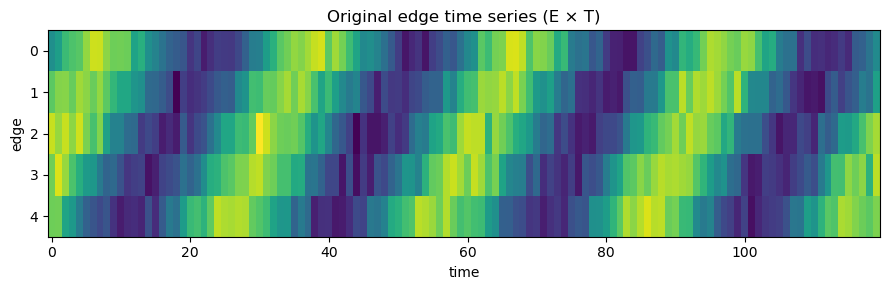

In [2]:
E, T = 5, 120
t = np.arange(T)

X = np.array([
    np.sin(2*np.pi*(t/30) + 0.6*e) + 0.15*rng.standard_normal(T)
    for e in range(E)
])

plt.figure(figsize=(9,3))
plt.imshow(X, aspect='auto')
plt.xlabel('time')
plt.ylabel('edge')
plt.title('Original edge time series (E × T)')
plt.tight_layout()
plt.show()

## 2. Independent circular time-shift per edge
Each edge is shifted by its own random offset.

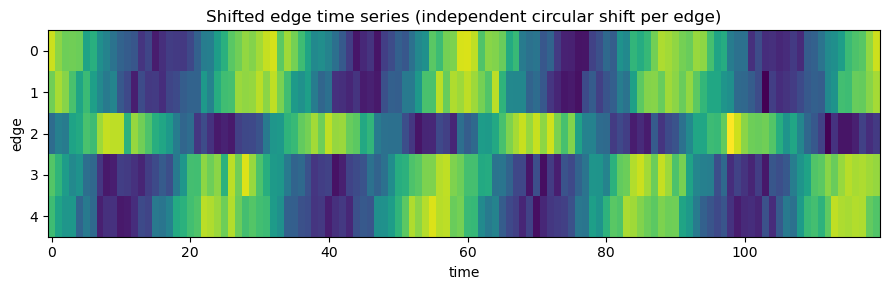

Shifts per edge: [113  85  68  27  89]


In [3]:
shifts = rng.integers(0, T, size=E)
X_shift = np.array([np.roll(X[e], shifts[e]) for e in range(E)])

plt.figure(figsize=(9,3))
plt.imshow(X_shift, aspect='auto')
plt.xlabel('time')
plt.ylabel('edge')
plt.title('Shifted edge time series (independent circular shift per edge)')
plt.tight_layout()
plt.show()

print('Shifts per edge:', shifts)

## 3. Overlay original vs shifted for selected edges
The waveform is preserved, only the temporal position changes.

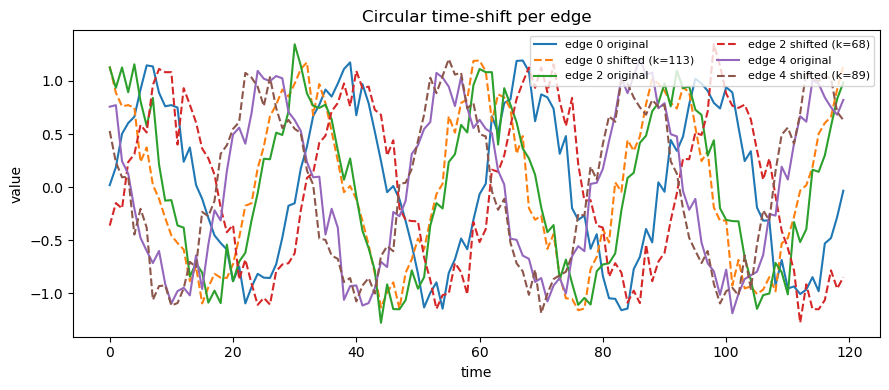

In [4]:
edges_to_show = [0, 2, 4]
plt.figure(figsize=(9,4))
for e in edges_to_show:
    plt.plot(t, X[e], label=f'edge {e} original')
    plt.plot(t, X_shift[e], '--', label=f'edge {e} shifted (k={shifts[e]})')
plt.xlabel('time')
plt.ylabel('value')
plt.title('Circular time-shift per edge')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Autocorrelation is preserved
Circular shifts preserve each edge’s temporal structure.

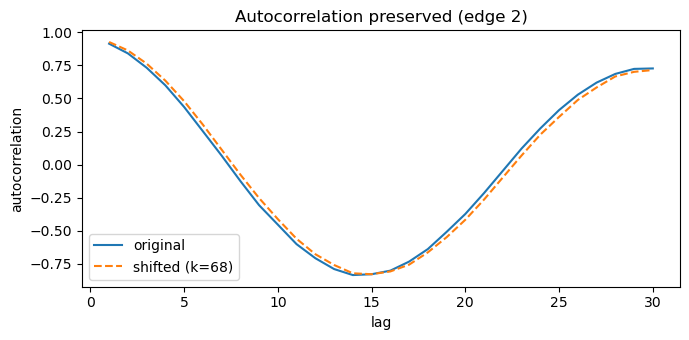

In [5]:
def autocorr(x, max_lag=30):
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([
        np.dot(x[:-lag], x[lag:]) / denom for lag in range(1, max_lag+1)
    ])

e = 2
lags = np.arange(1, 31)
plt.figure(figsize=(7,3.5))
plt.plot(lags, autocorr(X[e]), label='original')
plt.plot(lags, autocorr(X_shift[e]), '--', label=f'shifted (k={shifts[e]})')
plt.xlabel('lag')
plt.ylabel('autocorrelation')
plt.title(f'Autocorrelation preserved (edge {e})')
plt.legend()
plt.tight_layout()
plt.show()

## Take-home message
- Circular time shifts **destroy cross-edge synchrony**
- They **preserve per-edge temporal statistics**
- This makes them ideal surrogates for testing whether MC reflects
  genuine temporal coordination across edges.